# S&P 500 Equity+Options: Risk Controls

This notebook applies predeclared position-level risk rules to the allocation
lineage that ranks first on validation Sharpe among the full-coverage
candidates. It asks whether stop losses, trailing stops, or time exits improve
validation Sharpe and drawdown relative to the same no-overlay baseline. Every
measurement here comes from validation; the 2021 holdout is not read until
[`18_holdout_predictions`](18_holdout_predictions.ipynb).

**Learning objectives**

1. Carry the highest-ranked full-coverage allocation lineage into a
   controlled risk sweep.
2. Compare fixed stop-loss, trailing-stop, and time-exit rules.
3. Evaluate each overlay with a paired block-bootstrap Sharpe-difference
   interval against its exact no-overlay baseline.
4. Separate validation tuning from evidence of out-of-sample efficacy.

**Book reference:** Chapter 19, Sections 19.3-19.6.

**Prerequisites:** `15_portfolio_management` and the cost diagnostics in
`17_costs`. Signals form after Friday's close and execute at the next
available open, normally Monday. The current-constituent universe retains
survivorship bias. Results describe this retrospective roster during the
development window, not the historical index-membership process or a
prospective S&P 500 population.

In [1]:
"""S&P 500 Equity+Options: position-level risk-control sweep."""

import json
import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

Shared helpers keep strategy construction, execution, registry access, and
paired uncertainty consistent with the preceding pipeline stages.

In [2]:
from case_studies.research import (
    PLAN_STAGE_KEYS,
    CandidateSet,
    OfficialPopulation,
    Study,
    attest_sweep,
    candidate_set_supersedes,
    open_study,
    open_sweep_attempt,
    planned_backtests,
    population_supersedes,
    predictions_identity,
    resolve_field_members,
    sweep_labels,
    sweep_plan_name,
    unfinished_sweep_plans,
    upstream_plan_hashes,
)
from case_studies.utils.backtest_loaders import (
    VECTORIZED_CASE_STUDIES,
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    strategy_view,
)
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    model_source,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_position_risk_controls,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import (
    compute_paired_uncertainty,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [3]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
LABEL = ""
MAX_SYMBOLS = 0
MAX_RISK_VARIANTS = 0
TOP_N_COMBOS = None

### What is asked for, and what it resolves to

The parameters above are the request; the values this notebook runs on are resolved here under
different names, so a resolved value cannot overwrite the request that produced it. An injected
parameter wins; otherwise the case study's own declaration does.

In [4]:
# A preview run reads and registers in a smoke chain's own workspace, under `.preview/<case>`,
# and `open_study` is what activates that root. Activation rewrites `ML4T_OUTPUT_DIR` for the
# rest of the process, so it has to happen before the first `get_case_study_dir` rather than
# beside the registry read further down: `CASE_DIR` has to already answer for the workspace.
_preview_study = None
if EXECUTION_TIER == "preview":
    if not WORKSPACE:
        raise ValueError("preview execution requires WORKSPACE")
    _preview_study = open_study(
        CASE_STUDY_ID,
        execution_tier="preview",
        workspace=WORKSPACE,
        entry_point="16_risk_management",
    )
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
TOP_N = (
    TOP_N_COMBOS
    if TOP_N_COMBOS is not None
    else get_top_n_predictions(CASE_STUDY_ID, "risk_overlay")
)
RISK_LABEL = LABEL or bt_config.primary_label
if CASE_STUDY_ID in VECTORIZED_CASE_STUDIES:
    raise RuntimeError("This notebook requires engine-level position rules")

print(f"Case study: {CASE_STUDY_ID}; label: {RISK_LABEL}; selected lineages: {TOP_N}; mode: engine")

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; selected lineages: 1; mode: engine


## 1. Advance the highest-ranked eligible strategy carrier

Selection compares the equal-weight baseline with active alternative
allocators using validation Sharpe and maximum prediction coverage.
Historical rows from removed allocators cannot enter the corrected risk stage.

**The carrier is whichever strategy row ranks highest, so the pool it is drawn from decides what
is being overlaid.** A population is immutable and the registry keeps every generation of it, so
a pool built straight from `backtest_runs` counts retired members beside current ones - nothing
in the read path filters on supersession (`case_studies/utils/registry/queries.py` contains no
occurrence of `supersed`). A retired generation that outranks its own replacement would carry the
risk comparison, and the notebook would report an overlay on a strategy the case study no longer
publishes. `prediction_hashes` is passed rather than applied afterwards because it also scopes
the full-coverage bar the query ranks against: a retired row with a longer in-window count would
otherwise set a bar its live replacement cannot meet.

In [5]:
# `Study.at` is the read-only form: one root, no activation. These notebooks only read the
# populations - their backtests reach the registry by their own paths - and every other way in
# ends in `activate()`, which rewrites `ML4T_OUTPUT_DIR` process-wide. `open_study` with the
# canonical tier routes to `Study.regenerate`, which refuses unless `features`, `labels` and
# `run_log` are symlinks: true in a maintainer worktree, false in every clean clone and CI run.
# `CASE_DIR` is already the directory this notebook resolved, including under a preview, so
# asking it directly answers for the registry the rest of the notebook reads.
_study = (
    _preview_study
    if _preview_study is not None
    else Study.at(CASE_DIR, case_study=CASE_STUDY_ID, entry_point="16_risk_management")
)
_members, _population_notes = prediction_members_in_force(_study, CASE_DIR)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members
if CURRENT_MEMBERS is not None:
    print(f"{len(CURRENT_MEMBERS):,} prediction sets in the populations in force")

947 prediction sets in the populations in force


In [6]:
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY_ID)}
# The carrier is chosen out of the baseline and allocation grids, so both are required before
# either is ranked: their plans say which backtests the current grids contain, and their
# attestations say the runs that filled them finished. Ranking the registry unrestricted picks
# the carrier out of whatever historical rows survive, which is not the same question.
UPSTREAM_PLANS = upstream_plan_hashes(
    _study,
    case_study=CASE_STUDY_ID,
    label=RISK_LABEL,
    stage="risk_overlay",
    prediction_hashes=CURRENT_MEMBERS,
)
_stage_grids = {
    stage: planned_backtests(
        _study,
        case_study=CASE_STUDY_ID,
        label=RISK_LABEL,
        stage=stage,
        prediction_hashes=CURRENT_MEMBERS,
    )
    for stage in ("signal", "allocation")
}


def _within_plan(rows: pl.DataFrame, stage: str) -> pl.DataFrame:
    """The rows the current plan for this stage admits, or all of them where none is recorded."""
    grid = _stage_grids[stage]
    if grid is None:
        return rows
    return rows.filter(pl.col("backtest_hash").is_in(list(grid)))


baseline_pool = _within_plan(
    resolve_best_backtest_runs(
        CASE_STUDY_ID,
        RISK_LABEL,
        split="validation",
        stage="signal",
        top_n=9999,
        prediction_hashes=CURRENT_MEMBERS,
    ),
    "signal",
)
allocation_pool = _within_plan(
    resolve_best_backtest_runs(
        CASE_STUDY_ID,
        RISK_LABEL,
        split="validation",
        stage="allocation",
        top_n=9999,
        prediction_hashes=CURRENT_MEMBERS,
    ),
    "allocation",
)
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)
candidate_hashes = candidate_pool["prediction_hash"].unique().to_list()
if not candidate_hashes:
    raise RuntimeError("No full-coverage baseline or allocation candidates found")

Resolve model labels from prediction provenance, then filter the strategy
rows against the active allocator configuration.

In [7]:
with sqlite3.connect(REGISTRY_DB) as db:
    source_rows = db.execute(
        f"""
        SELECT p.prediction_hash, t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash IN ({",".join("?" for _ in candidate_hashes)})
        """,
        candidate_hashes,
    ).fetchall()
source_by_hash = {
    prediction_hash: model_source(family, config_name)
    for prediction_hash, family, config_name in source_rows
}

eligible_rows = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_rows.append(
            {
                **row,
                "source": source_by_hash[row["prediction_hash"]],
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )

if len(eligible_rows) < TOP_N:
    raise RuntimeError(f"Expected {TOP_N} eligible strategy lineages, found {len(eligible_rows)}")
top_combos = pl.DataFrame(eligible_rows).sort("sharpe", descending=True).head(TOP_N)
carrier = top_combos.row(0, named=True)
print(
    f"Selected {carrier['source']} with {carrier['allocator']} allocation, "
    f"top-{carrier['top_k']}, validation Sharpe {carrier['sharpe']:.3f}"
)

Selected gbm/default_mae with mvo_ledoit_wolf allocation, top-5, validation Sharpe 1.154


The cell above names the lineage this run resolved to. The baseline stays
fixed while the risk rule changes, so every comparison is a paired strategy
perturbation rather than a new model-selection contest.

In [8]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    RISK_LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
print(
    f"Price support: {len(prices):,} rows across {prices['symbol'].n_unique()} historical symbols"
)

Price support: 505,922 rows across 614 historical symbols


## 2. Build the risk-control surface

The sweep uses only the rules declared in `setup.yaml`. A prior version
derived additional MAE thresholds from the full validation price panel and
evaluated them on that same panel. Those tuned-on-validation rules are not
eligible for corrected v3.1 selection.

In [9]:
position_controls = get_position_risk_controls(CASE_STUDY_ID)
if MAX_RISK_VARIANTS > 0:
    position_controls = position_controls[:MAX_RISK_VARIANTS]
if not position_controls:
    raise RuntimeError("No position-level risk controls configured")

base_specs = []
for combo in top_combos.iter_rows(named=True):
    prediction_hash = combo["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo["spec_json"]),
        prices=prices,
        prediction_hash=prediction_hash,
        initial_cash=bt_config.initial_cash,
    )
    base_specs.append((combo, prediction_hash, base_spec))

Each declared rule changes only the position-risk block of its carrier's
strategy specification.

In [10]:
plans = []
for combo, prediction_hash, base_spec in base_specs:
    for control in position_controls:
        spec = clone_backtest_spec(base_spec)
        spec["chapter"] = "ch19"
        rule = {"type": control["type"]}
        if control["type"] == "time_exit":
            rule["bars"] = control["bars"]
        else:
            rule["threshold"] = control["threshold"]
        spec["strategy"]["risk"] = {
            "name": control["name"],
            "position_rules": [rule],
        }
        plans.append(
            {
                "risk_name": control["name"],
                "risk_type": control["type"],
                "source": combo["source"],
                "allocator": combo["allocator"],
                "prediction_hash": prediction_hash,
                "baseline_hash": combo["backtest_hash"],
                "spec": spec,
                "backtest_hash": backtest_hash_from_parts(prediction_hash, spec),
            }
        )

In [11]:
with sqlite3.connect(REGISTRY_DB) as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}
cached = sum(plan["backtest_hash"] in existing_hashes for plan in plans)
print(f"Planned {len(plans)} risk backtests; {cached} already complete")

Planned 14 risk backtests; 14 already complete


Rules execute inside the event-driven engine on one precomputed allocation
path. Missing rows fail the production run; cached hashes are reused.

A shared weight path isolates the position rule as the only difference among
a carrier's risk variants.

In [12]:
def execute_risk_plans(combo: dict, combo_plans: list[dict]) -> list[str]:
    combo_failures = []
    predictions = read_predictions(CASE_STUDY_ID, combo["prediction_hash"])
    weights = precompute_weights(
        predictions,
        combo_plans[0]["spec"],
        prices,
        label=RISK_LABEL,
        case_study=CASE_STUDY_ID,
        prediction_hash=combo["prediction_hash"],
    )
    for index, plan in enumerate(combo_plans, start=1):
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                combo["prediction_hash"],
                plan["spec"],
                prices=prices,
                predictions=predictions,
                label=RISK_LABEL,
                register=True,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
                precomputed_weights=weights,
            )
            existing_hashes.add(plan["backtest_hash"])
            print(
                f"[{index}/{len(combo_plans)}] {plan['risk_name']}: "
                f"Sharpe={result.metrics['sharpe']:.3f}; "
                f"max drawdown={result.metrics['max_drawdown']:.1%}",
                flush=True,
            )
        except Exception as exc:  # noqa: BLE001
            combo_failures.append(f"{plan['backtest_hash']} {plan['risk_name']}: {exc}")
    return combo_failures

### Record the grid before running it

`plans` is every overlay backtest this sweep intends to register, identified before any of
them executes, and the loop below raises rather than dropping one. Publishing it as an
official population is what lets the freeze below tell an interrupted sweep from a finished
one. No reading of the registered rows can: an interruption leaves rows that look exactly
like a smaller finished grid, whether they are counted as rows, as model configurations, or
as stages present.

Published before the sweep and checked with `require_complete` after, for the reason
`15_portfolio_management` gives: written at the end, a changed sweep stays represented by the
previous generation, which is complete, so an interrupted re-run under a widened grid reports
as finished on a plan it has already replaced.

In [13]:
# The name carries which prediction sets the sweep planned against, for the reason
# `15_portfolio_management` gives at its own plan.
RISK_POPULATION = sweep_plan_name(
    CASE_STUDY_ID, RISK_LABEL, "risk_overlay", predictions_identity(CURRENT_MEMBERS)
)
# The generation this run retires, per population name. A plan that has grown - a new carrier
# advancing, another risk control declared - is a changed population under a live name and has
# to say which one it replaces; the refusal prints the current hash.
# All five moved with the allocation plans above them: the risk grid is built over the strategy
# 15_portfolio_management selects, and that selection changed for the labels whose top-ten was
# ranked before the baseline sweep finished.
# Empty, for the reason `SUPERSEDES_ALLOCATION_POPULATIONS` is: a declaration naming the
# generation in force pre-authorizes a membership change under that name instead of recording
# one that happened. Add an entry when a run is refused, with the hash the refusal prints.
SUPERSEDES_RISK_POPULATIONS: dict[str, str] = {}

_risk_plan = None
try:
    _risk_writable = (
        _preview_study
        if _preview_study is not None
        else open_study(CASE_STUDY_ID, entry_point="16_risk_management")
    )
except PermissionError as exc:
    print(f"Not recording the risk plan here: {exc}")
else:
    # A preview's `root` stays the case directory while its writes go to the workspace, so
    # the registry this run writes is `storage_root` for its tier. At canonical the two are
    # identical and the guard is exactly as strict as before.
    if _risk_writable.storage_root(EXECUTION_TIER) != CASE_DIR:
        raise RuntimeError(
            f"16 ran its sweep against {CASE_DIR} but opened a study rooted at "
            f"{_risk_writable.root}. Recording the plan there would describe a registry this "
            "run did not write."
        )
    if EXECUTION_TIER != "canonical":
        # `OfficialPopulation.create` refuses a preview, and rightly: a published population is
        # a durable claim about what this case study publishes, and a preview is discarded with
        # its workspace. The risk sweep still executes and still registers. `_risk_plan` stays
        # None, which the attestation below already tests for.
        print(
            f"{EXECUTION_TIER} tier: the risk sweep executes and registers, and publishes no "
            f"official population under {RISK_POPULATION}."
        )
    else:
        _risk_plan = OfficialPopulation.create(
            _risk_writable,
            name=RISK_POPULATION,
            member_kind="backtest",
            members=[plan["backtest_hash"] for plan in plans],
            supersedes=population_supersedes(
                _risk_writable,
                name=RISK_POPULATION,
                declared=SUPERSEDES_RISK_POPULATIONS.get(RISK_POPULATION),
            ),
        )
        # Before any member executes; see `sweep_attestation_name`.
        _attempt = open_sweep_attempt(_risk_writable, _risk_plan, UPSTREAM_PLANS)
        print(
            f"Risk plan {RISK_POPULATION}: {_risk_plan.hash}, {len(plans)} planned, attempt {_attempt}"
        )

Risk plan sp500_equity_option_analytics-risk-fwd_ret_5d-5e587e1afb1a: d3b3085fe43b, 14 planned, attempt 3


In [14]:
failures = []
started = time.monotonic()
for combo in top_combos.iter_rows(named=True):
    combo_plans = [
        plan
        for plan in plans
        if plan["prediction_hash"] == combo["prediction_hash"]
        and plan["backtest_hash"] not in existing_hashes
    ]
    if combo_plans:
        failures.extend(execute_risk_plans(combo, combo_plans))

In [15]:
if failures:
    raise RuntimeError("Risk-sweep failures:\n" + "\n".join(failures))
print(f"Risk surface complete in {(time.monotonic() - started):.1f}s")
if _risk_plan is not None:
    _risk_plan.require_complete()
    # Only a run that raised on nothing reaches this. See `sweep_attestation_name`.
    _attestation = attest_sweep(_risk_writable, _risk_plan, _attempt, UPSTREAM_PLANS)
    print(f"Risk plan {RISK_POPULATION} complete: {len(plans)} backtests")
    print(f"Sweep attested as {_attestation.name}")

Risk surface complete in 0.0s


Risk plan sp500_equity_option_analytics-risk-fwd_ret_5d-5e587e1afb1a complete: 14 backtests
Sweep attested as sp500_equity_option_analytics-risk-fwd_ret_5d-5e587e1afb1a-g19caab94bde7-swept-3


## 3. Measure paired overlay effects

The registry query is keyed by the hashes planned above. Each overlay's
return series is aligned by timestamp with its exact allocation baseline,
then the same stationary-bootstrap indices are applied to both paths.

In [16]:
plan_meta = pl.DataFrame(
    [
        {
            "backtest_hash": plan["backtest_hash"],
            "baseline_hash": plan["baseline_hash"],
            "risk_name": plan["risk_name"],
            "risk_type": plan["risk_type"],
            "source": plan["source"],
            "allocator": plan["allocator"],
        }
        for plan in plans
    ]
)
placeholders = ",".join("?" for _ in plans)
with sqlite3.connect(REGISTRY_DB) as db:
    metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe, bm.max_drawdown, bm.num_trades
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({placeholders})
        """,
        connection=db,
        execute_options={"parameters": [plan["backtest_hash"] for plan in plans]},
    )

risk_results = plan_meta.join(metrics, on="backtest_hash", how="inner")
if len(risk_results) != len(plans):
    raise RuntimeError(f"Expected {len(plans)} risk rows, found {len(risk_results)}")
if risk_results.filter(pl.col("stage") != "risk_overlay").height:
    raise RuntimeError("A planned risk hash was registered under the wrong stage")

A paired comparison aligns each overlay with its exact no-overlay carrier,
drops their shared inactive prefix, and resamples both paths together.

In [17]:
def paired_overlay_metrics(row: dict) -> dict:
    baseline = load_daily_returns_with_timestamp(CASE_STUDY_ID, row["baseline_hash"])
    challenger = load_daily_returns_with_timestamp(CASE_STUDY_ID, row["backtest_hash"])
    if baseline is None or challenger is None:
        raise RuntimeError(f"Missing daily returns for {row['risk_name']}")
    aligned = (
        baseline.rename({"ret": "baseline_ret"})
        .join(challenger.rename({"ret": "challenger_ret"}), on="timestamp", how="inner")
        .sort("timestamp")
    )
    if aligned.is_empty():
        raise RuntimeError(f"Degenerate return pair for {row['risk_name']}")
    # The leading inactive sessions are dropped inside `compute_paired_uncertainty`, over both
    # series at once. Trimming per series is what broke this cell: an overlay sits out sessions
    # its carrier trades, so the two sides arrived at different lengths and the paired bootstrap
    # refused every one of them.
    #
    # `challenger_overlays_baseline` says which pair this is, and here it is an overlay running
    # on top of its carrier: both are live from the carrier's first traded session, so a session
    # the overlay sits out is a position it chose to hold and stays in. It is the effect being
    # measured. The default would drop those rows, which is right for a strategy that has a
    # warmup before its first signal and wrong for every rule below.
    paired = compute_paired_uncertainty(
        aligned["challenger_ret"],
        aligned["baseline_ret"],
        periods_per_year=periods_per_year_from_setup(CASE_STUDY_ID),
        case_study=CASE_STUDY_ID,
        label=RISK_LABEL,
        n_boot=2000,
        seed=42,
        challenger_overlays_baseline=True,
    )
    if not paired:
        raise RuntimeError(
            f"Paired uncertainty failed for {row['risk_name']}: the overlay and its carrier "
            f"share {aligned.height} sessions, and too few of them fall after the first one "
            "either side traded. A bootstrap needs at least four."
        )
    return {
        "backtest_hash": row["backtest_hash"],
        "sharpe_diff": paired["sharpe_diff"],
        "sharpe_diff_ci_lo": paired["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci_hi": paired["sharpe_diff_ci95_hi"],
        "prob_overlay_wins": paired["prob_challenger_wins"],
    }

In [18]:
paired_rows = [paired_overlay_metrics(row) for row in risk_results.iter_rows(named=True)]

risk_results = risk_results.join(pl.DataFrame(paired_rows), on="backtest_hash").sort(
    "sharpe", descending=True
)

The chart below ranks every overlay by its paired Sharpe difference against
its own no-overlay carrier. What separates an overlay worth carrying forward
from one that is not is whether its bootstrap interval clears zero, not the
size of the point difference. With every declared rule scored on a single
validation path, a large point difference whose interval spans zero is what
selection noise looks like.

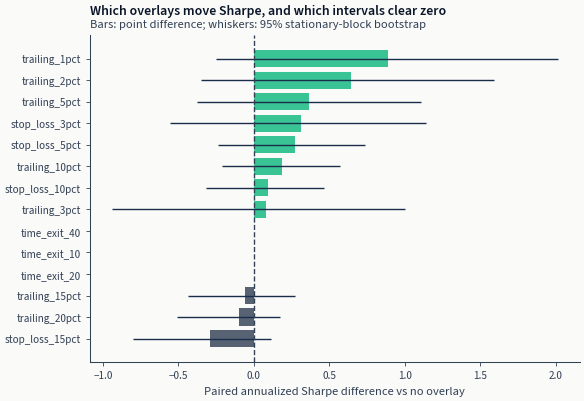

In [19]:
plot_risk = risk_results.sort("sharpe_diff")
fig_delta, ax_delta = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)

points = plot_risk["sharpe_diff"].to_list()
lo = plot_risk["sharpe_diff_ci_lo"].to_list()
hi = plot_risk["sharpe_diff_ci_hi"].to_list()
colors = [COLORS["positive"] if point > 0 else COLORS["neutral"] for point in points]
y = list(range(len(plot_risk)))
ax_delta.barh(y, points, color=colors, alpha=0.82)
ax_delta.errorbar(
    points,
    y,
    xerr=[
        [point - lower for point, lower in zip(points, lo, strict=True)],
        [upper - point for point, upper in zip(points, hi, strict=True)],
    ],
    fmt="none",
    ecolor=COLORS["slate"],
    capsize=2,
    linewidth=1,
)
ax_delta.axvline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax_delta.set_yticks(y, plot_risk["risk_name"].to_list(), fontsize=8)
ax_delta.set_xlabel("Paired annualized Sharpe difference vs no overlay")
add_message_title(
    ax_delta,
    "Which overlays move Sharpe, and which intervals clear zero",
    "Bars: point difference; whiskers: 95% stationary-block bootstrap",
)
fig_delta.show()

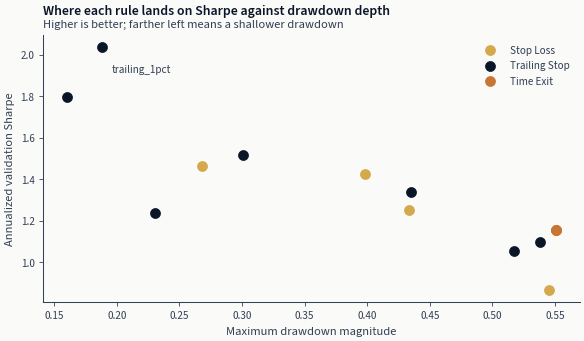

In [20]:
fig_tradeoff, ax_tradeoff = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
type_colors = {
    "stop_loss": COLORS["amber"],
    "trailing_stop": COLORS["blue"],
    "time_exit": COLORS["copper"],
}
for risk_type, color in type_colors.items():
    subset = risk_results.filter(pl.col("risk_type") == risk_type)
    ax_tradeoff.scatter(
        -subset["max_drawdown"],
        subset["sharpe"],
        s=52,
        color=color,
        label=risk_type.replace("_", " ").title(),
    )
top_overlay = risk_results.row(0, named=True)
ax_tradeoff.annotate(
    top_overlay["risk_name"],
    (-top_overlay["max_drawdown"], top_overlay["sharpe"]),
    xytext=(7, -12),
    textcoords="offset points",
    fontsize=8,
    va="top",
)
ax_tradeoff.set_xlabel("Maximum drawdown magnitude")
ax_tradeoff.set_ylabel("Annualized validation Sharpe")
ax_tradeoff.legend(frameon=False)
add_message_title(
    ax_tradeoff,
    "Where each rule lands on Sharpe against drawdown depth",
    "Higher is better; farther left means a shallower drawdown",
)

fig_tradeoff.show()

## 4. Freeze the field the holdout will choose from

This is the last stage that ranks. Everything after it - the cost surface, the
holdout refit, the holdout backtest - acts on one configuration, and which one
that is has to be decided here rather than re-derived four times from a
registry that keeps moving underneath. So the field is written down as an
immutable candidate set, and `18_holdout_predictions`, `19_holdout_backtest`
and `20_strategy_analysis` read the selection out of it instead of each
applying the ranking rule again and hoping the four agree.

The members are the three stages that competed: the equal-weight baselines,
the allocation variants, and the risk overlays laid over them, restricted to
the prediction sets currently in force. All three matter. A pool of overlays
alone would force an overlay onto the carrier even where every control hurt
it, because this stage registers a row per named control and none for the
strategy it was overlaid on. A pool without the baselines would make a bare
equal-weight top-k unreachable, which is a legitimate answer whenever neither
allocation nor risk earned its complexity.

The comparison contract names what every member must agree on, so a backtest
fitted against different labels, features or folds cannot quietly join a set
the holdout will pick from.

**The field spans every declared label, not the one this run overlaid.** The risk sweep above
is per label - it perturbs one carrier, drawn from one label's strategies - but the selection
this set exists to make is not: the holdout picks the single highest validation backtest Sharpe
the case study produced, and a label that never entered the set cannot be picked no matter how
it scored. Resolving the field against `RISK_LABEL` made the membership depend on which label
happened to run last, which is both the wrong field and a set that changes under a fixed name
on every label - so the second label's run could not publish at all.

In [21]:
# A candidate set is immutable under its name, so a field whose membership has moved has to name
# the generation it replaces. Keyed by the full set name because that is what the refusal prints.
# Resolved through `candidate_set_supersedes` rather than passed straight to `create`: a
# reader's clean clone has no generation to supersede, and `create` refuses a first version that
# claims to replace one. Five generations precede this one and all five stay readable by hash,
# which is what keeps a holdout registered against any of them traceable to the field it saw:
# `328d2009685c` is the single-label field frozen on 2026-08-30 with 1,097 members, before the
# four variant labels had baseline, allocation or overlay rows; `aa6b3986124b` replaced it on
# 2026-09-01 with 3,680 under a per-stage count of advancing configurations, which admitted a
# label whose sweep had produced one row per configuration and stopped; `04cb35eec43f` replaced
# that one later the same day and held 3,710, 66 of them allocation backtests from a grid no
# current sweep plan declares; `37169a5be187` replaced it with the declared grids only and held
# 3,644; `774c32c6e79b` replaced that with 3,811. All five were frozen over a field that was
# still being produced: the allocation and risk plans behind them were written at 21:40 UTC on
# 2026-09-01, while the baseline sweeps that feed them published at 22:34-22:46 and three of the
# baselines they rank were registered at 22:42. `57cb9eb3133c` is the tip, frozen 2026-09-02
# over sweeps that ran in stage order and recorded that they finished. It holds 3,811 as well and
# differs from `774c32c6e79b` in 54 members: the `fwd_ret_10d` allocation backtests registered at
# 00:55 on 2026-09-01 gave way to the 54 the re-executed 15 registered at 00:30 on 2026-09-02, so
# every member now rides an attestation that carries its own grid. Only the tip is declarable -
# `create` refuses anything else and names the tip - so this value moves on every generation, and
# it is wrong whenever it names a generation the registry has already superseded.
SUPERSEDES_CANDIDATE_SETS: dict[str, str] = {
    "sp500_equity_option_analytics:holdout-candidates": "57cb9eb3133c",
}

Freezing writes to the registry, which needs the study opened rather than read.
That is a maintainer path: a reader's clean clone has no `run_log/` to freeze
from, so the cell reports why it did nothing instead of failing.

In [22]:
CANDIDATE_SET_NAME = f"{CASE_STUDY_ID}:holdout-candidates"
candidate_stages = ("signal", "allocation", "risk_overlay")
CANDIDATE_LABELS = sweep_labels(_study)
# The plans are asked for first, before the field is built rather than after it.
# `resolve_field_members` builds each downstream stage from the plan recorded for the
# predictions in force and raises where one is absent, because a stage whose sweep has not run
# against them holds rows from another generation and there is no correct field to return. That
# is what a reader rebuilding this field live needs. Here it would turn the ordinary sequential
# case into a failure: 15 and 16 run for each label in turn, and every run but the last finds
# some other label's plan missing. Asking first keeps that a decline.
#
# Every declared label is asked, not the ones the rows suggest advanced. A label that has not
# started and a label deliberately stopped at its baseline leave the registry in the same state,
# so inferring the wait-set from the rows lets whichever label ran first seal the field and lock
# the rest out. There is no funnel to accommodate here: 15 raises rather than advancing fewer
# configurations than declared, so no label stops at its baseline.
unfinished = unfinished_sweep_plans(
    _study,
    case_study=CASE_STUDY_ID,
    labels=CANDIDATE_LABELS,
    prediction_hashes=CURRENT_MEMBERS,
)
if unfinished:
    # The denominator is derived, not written down. There is one plan per (label, planned
    # stage), and the baseline became a planned stage after this message was first written -
    # so a hardcoded two per label reports a fraction whose numerator can exceed it, and
    # names the wrong notebooks to run.
    print(
        f"Not freezing a candidate set here: {len(unfinished)} of "
        f"{len(PLAN_STAGE_KEYS) * len(CANDIDATE_LABELS)} recorded sweep plans are absent or "
        "incomplete, so the field is still being produced. Run 14, 15 and 16 for each declared "
        "label; the last of those runs freezes the set. Declining is not a failure - this "
        "notebook has done its own label's work either way, and the set is written exactly "
        "once.\n  " + "\n  ".join(unfinished)
    )

# One construction, shared with the four stages that read this field. It requires every
# declared label to have rankable baseline rows, because every label is backtested equal-weight
# and an absent one means the baseline sweep is unfinished.
frozen_pool = (
    None
    if unfinished
    else resolve_field_members(
        _study,
        case_study=CASE_STUDY_ID,
        prediction_hashes=CURRENT_MEMBERS,
        resolve_best_backtest_runs=resolve_best_backtest_runs,
        stages=candidate_stages,
    )
)
if frozen_pool is not None:
    print(
        f"Field to freeze: {frozen_pool.height} eligible validation backtests "
        f"across {candidate_stages} and {len(CANDIDATE_LABELS)} labels"
    )

try:
    if unfinished:
        raise PermissionError(
            "the sweep plans reported above are not all complete for the predictions in force"
        )
    writable = (
        _preview_study
        if _preview_study is not None
        else open_study(CASE_STUDY_ID, entry_point="16_risk_management")
    )
except PermissionError as exc:
    holdout_candidates = None
    print(
        f"Not freezing a candidate set here: {exc}. The set is a maintainer artifact written "
        "alongside the registry this notebook reads; a clean clone has neither, and the "
        "holdout notebooks name it when they cannot find it."
    )
else:
    # `open_study` activates, and activation decides which case directory this process reads and
    # writes. If that is not the directory the pool above was resolved from, the set would be
    # written where 17 through 20 will not look for it, and its members would be opened from a
    # root other than the one they will be read back from - which is how a member that is
    # complete at freeze time is incomplete at read time. Refusing is better than writing a set
    # nobody reads.
    # A preview's `root` stays the case directory while its writes go to the workspace, so
    # the registry this run writes is `storage_root` for its tier. At canonical the two are
    # identical and the guard is exactly as strict as before.
    if writable.storage_root(EXECUTION_TIER) != CASE_DIR:
        raise RuntimeError(
            f"16 resolved its candidate field from {CASE_DIR} but opened a study rooted at "
            f"{writable.root}. Freezing here would write the set where the holdout notebooks "
            "will not find it, and check its members against different artifacts than they "
            "will read."
        )
    members = [
        writable.results.open(backtest_hash)
        for backtest_hash in frozen_pool["backtest_hash"].to_list()
    ]
    # Named here rather than left to `create`, which reports the first partial member and stops.
    # A field that cannot be frozen is a field the holdout stage cannot select from, so what a
    # reader needs is how many members are unusable and why, not the first one alphabetically.
    incomplete = [
        (member.hash, reason) for member in members if (reason := member.completeness()) is not None
    ]
    if incomplete:
        raise RuntimeError(
            f"{len(incomplete)} of {len(members)} eligible backtests are incomplete, so the "
            "field cannot be frozen: "
            + "; ".join(f"{hash_} ({reason})" for hash_, reason in incomplete[:5])
            + ("" if len(incomplete) <= 5 else f"; and {len(incomplete) - 5} more")
        )
    holdout_candidates = CandidateSet.create(
        writable,
        name=CANDIDATE_SET_NAME,
        members=members,
        comparison_contract={"comparable_fields": ["label_artifact", "feature_artifacts", "cv"]},
        supersedes=candidate_set_supersedes(
            writable,
            name=CANDIDATE_SET_NAME,
            declared=SUPERSEDES_CANDIDATE_SETS.get(CANDIDATE_SET_NAME),
        ),
    )
    frozen_selection = holdout_candidates.best_validation_sharpe()
    print(
        f"Frozen candidate set {holdout_candidates.hash}: {len(holdout_candidates.members)} members"
    )
    print(f"Validation-selected backtest: {frozen_selection.hash}")

Field to freeze: 3811 eligible validation backtests across ('signal', 'allocation', 'risk_overlay') and 5 labels


Frozen candidate set 7fd2e57b3796: 3811 members
Validation-selected backtest: c8212eda3bca


## Key takeaways

1. Risk selection is validation-only. It carries the eligible lineage that
   ranks first on validation Sharpe forward without consulting the holdout.
2. Every overlay is scored against its own carrier's no-overlay path, so the
   position rule is the only difference inside a pair.
3. An overlay earns a claim only where its paired bootstrap interval excludes
   zero. The ordering of point differences on its own establishes nothing.
4. Full-validation MAE-calibrated thresholds are excluded from corrected
   v3.1 because their thresholds were learned from the same validation paths
   used to score them.
5. The predeclared overlays are a selection cohort, and the winner of one is a
   validation result. The holdout is what says whether it survives, and it is
   read on the final carrier rather than used to choose among these.
6. The field is frozen here as an immutable candidate set. That is what stops
   the four stages after this one from each re-deriving a selection, and what
   makes the configuration the holdout was run on a matter of record rather
   than a rule four notebooks apply consistently until one of them does not.
7. The overlay sweep is per label; the field it feeds is not. Each label gets
   its own carrier and its own controls, and every label's strategies then
   compete in one set, because the holdout picks one configuration for the
   case study rather than one per label.

**Next:** [`17_costs`](17_costs.ipynb) stresses whichever configuration this stage
advances - the best overlay, or the un-overlaid carrier where no overlay helped -
across the cost surface. See Chapter 20 for the strategy synthesis framework.